# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [1]:
import pandas as pd

# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [2]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [3]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

In [4]:
# 1. Imports
import pandas as pd
import numpy as np
import spacy
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Load English NLP model (this requires python -m spacy download en_core_web_sm to be run first in the environment)
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

# 2. Modular Function for NLP Tokenization
def spacy_tokenizer(document):
    """
    Tokenizes and normalizes text by lemmatizing and removing stop words/punctuation.
    """
    if not isinstance(document, str):
        return []
    
    tokens = nlp(document)
    return [
        token.lemma_.lower().strip() 
        for token in tokens 
        if not token.is_stop and not token.is_punct and not token.is_space
    ]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 27.6 MB/s eta 0:00:0000:010:01



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Data Exploration

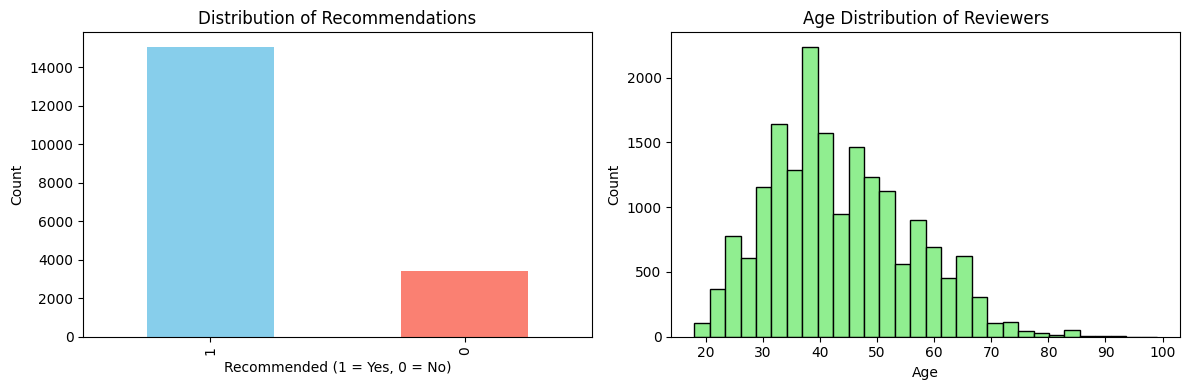

In [5]:
import matplotlib.pyplot as plt

def explore_data(df):
    """Generates basic data exploration visualizations."""
    plt.figure(figsize=(12, 4))
    
    # Target variable distribution
    plt.subplot(1, 2, 1)
    df['Recommended IND'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
    plt.title('Distribution of Recommendations')
    plt.xlabel('Recommended (1 = Yes, 0 = No)')
    plt.ylabel('Count')

    # Age distribution
    plt.subplot(1, 2, 2)
    df['Age'].plot(kind='hist', bins=30, color='lightgreen', edgecolor='black')
    plt.title('Age Distribution of Reviewers')
    plt.xlabel('Age')
    plt.ylabel('Count')
    
    plt.tight_layout()
    plt.show()

# Run the exploration on the original dataframe
explore_data(data)

## Building Pipeline

In [12]:
from sklearn.preprocessing import FunctionTransformer

def build_model_pipeline():
    """Builds a complete ML pipeline handling mixed data types."""
    
    # 1. Numerical Features Pipeline
    numeric_features = ['Age', 'Positive Feedback Count']
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # 2. Categorical Features Pipeline
    categorical_features = ['Clothing ID', 'Division Name', 'Department Name', 'Class Name']
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # 3. Text Features Pipeline (Using 'Review Text' as the primary text feature)
    text_features = 'Review Text'
    text_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='')),
        # We need to flatten the 2D array from ColumnTransformer for the Vectorizer
        ('flatten', FunctionTransformer(np.ravel, accept_sparse=True)),
        # Add token_pattern=None to silence the warning
        ('tfidf', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, max_features=500)) 
    ])

    # 4. Combine Preprocessing Steps
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features),
            ('text', text_transformer, [text_features]) # Pass as list for ColumnTransformer
        ])

    # 5. Final Pipeline with Classifier
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])
    
    return pipeline

pipeline = build_model_pipeline()

## Training Pipeline

In [15]:
# Train the initial pipeline on the training data
print("Training the base pipeline... (This may take a few minutes due to NLP processing)")
pipeline.fit(X_train, y_train)
print("Base model trained successfully!")

Training the base pipeline... (This may take a few minutes due to NLP processing)
Base model trained successfully!


## Fine-Tuning Pipeline

In [18]:
def fine_tune_model(pipeline, X_train, y_train):
    """Uses GridSearchCV to find optimal hyperparameters."""
    
    # SHRUNK GRID: Only 2 combinations total
    param_grid = {
        'preprocessor__text__tfidf__max_features': [500],
        'classifier__n_estimators': [50, 100], # Only testing these two
        'classifier__max_depth': [None]
    }

    grid_search = GridSearchCV(
        pipeline, 
        param_grid, 
        cv=2, # SHRUNK CV: 2 folds instead of 3
        n_jobs=1, 
        scoring='accuracy',
        verbose=2
    )

    print("Starting Grid Search...")
    grid_search.fit(X_train, y_train)
    print(f"Best Parameters: {grid_search.best_params_}")
    
    return grid_search.best_estimator_

best_model = fine_tune_model(pipeline, X_train, y_train)

Starting Grid Search...
Fitting 2 folds for each of 2 candidates, totalling 4 fits
[CV] END classifier__max_depth=None, classifier__n_estimators=50, preprocessor__text__tfidf__max_features=500; total time= 3.5min
[CV] END classifier__max_depth=None, classifier__n_estimators=50, preprocessor__text__tfidf__max_features=500; total time= 3.2min
[CV] END classifier__max_depth=None, classifier__n_estimators=100, preprocessor__text__tfidf__max_features=500; total time= 3.3min
[CV] END classifier__max_depth=None, classifier__n_estimators=100, preprocessor__text__tfidf__max_features=500; total time= 3.2min
Best Parameters: {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'preprocessor__text__tfidf__max_features': 500}


## Model Evaluation


In [19]:
def evaluate_model(model, X_test, y_test):
    """Evaluates the model using accuracy, precision, and recall metrics."""
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    print("\n--- Model Evaluation ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred))

# Evaluate the best pipeline
evaluate_model(best_model, X_test, y_test)


--- Model Evaluation ---
Accuracy:  0.8515
Precision: 0.8620
Recall:    0.9756

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.28      0.40       327
           1       0.86      0.98      0.92      1518

    accuracy                           0.85      1845
   macro avg       0.79      0.63      0.66      1845
weighted avg       0.83      0.85      0.82      1845

